In [ ]:
import os
import pandas as pd
import sys
from dataset import ApplyCLAHE, LetterboxPad
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
CSV_PATH = '../data/Data_Entry_2017.csv'
df = pd.read_csv(CSV_PATH)

print(f"Dataframe loaded: {len(df)} rows")
df.head()

Dataframe loaded: 112120 rows


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
image_root = '../images'
path_map = {}

print("Indexing images across folders... (this may take a moment)")
for i in range(1, 13):
    # This matches the NIH folder structure: images_001/images/0001.png
    folder_path = os.path.join(image_root, f"images_{str(i).zfill(3)}", "images")
    
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg')):
                path_map[filename] = os.path.join(folder_path, filename)

print(f"Total images indexed: {len(path_map)}")

def get_full_path(img_name):
    """Helper to get path; returns None if image not found"""
    return path_map.get(img_name)

Indexing images across folders... (this may take a moment)
Total images indexed: 112120


In [4]:
# Standardize 'No Finding' and split the labels
df['Finding Labels'] = df['Finding Labels'].fillna('No Finding')
df['Label_List'] = df['Finding Labels'].str.split('|')

# Quick check on the most frequent diseases
all_labels = [label for sublist in df['Label_List'] for label in sublist]
label_counts = Counter(all_labels)
print(label_counts.most_common())

[('No Finding', 60361), ('Infiltration', 19894), ('Effusion', 13317), ('Atelectasis', 11559), ('Nodule', 6331), ('Mass', 5782), ('Pneumothorax', 5302), ('Consolidation', 4667), ('Pleural_Thickening', 3385), ('Cardiomegaly', 2776), ('Emphysema', 2516), ('Edema', 2303), ('Fibrosis', 1686), ('Pneumonia', 1431), ('Hernia', 227)]


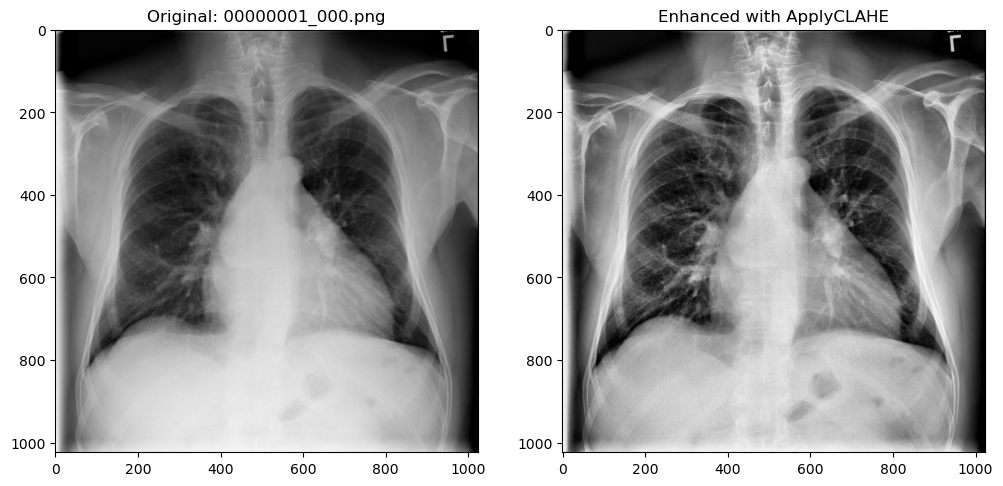

In [5]:
# Pick any image index from the dataframe
sample_img_name = df['Image Index'].iloc[0] 

# Use your new helper function!
img_path = get_full_path(sample_img_name)

if img_path:
    # 1. Load Original
    raw_cv2 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    raw_pil = Image.fromarray(raw_cv2)

    # 2. Apply your custom Transform from dataset.py
    clahe_transform = ApplyCLAHE(clip_limit=2.0)
    enhanced_pil = clahe_transform(raw_pil)

    # 3. Visualize
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(raw_cv2, cmap='gray')
    ax[0].set_title(f"Original: {sample_img_name}")
    ax[1].imshow(np.array(enhanced_pil), cmap='gray')
    ax[1].set_title("Enhanced with ApplyCLAHE")
    plt.show()
else:
    print(f"Error: Could not find {sample_img_name} in the images folders.")

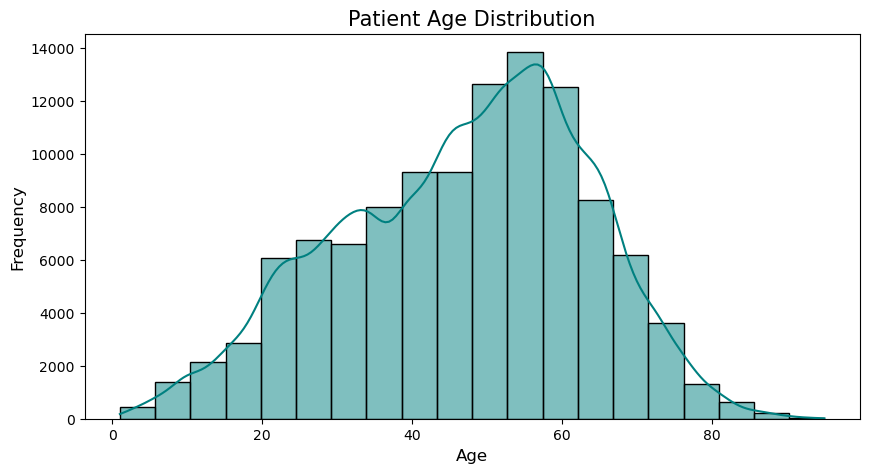

In [6]:
def plot_age_distribution(df):
    # Filter out or clip extreme outliers for visualization
    valid_ages = df[df['Patient Age'] <= 100]['Patient Age']

    plt.figure(figsize=(10, 5))
    sns.histplot(valid_ages, bins=20, kde=True, color='teal')
    plt.title('Patient Age Distribution', fontsize=15)
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()

plot_age_distribution(df)

In [7]:
def compare_clahe(image_path):
    # Load raw image
    raw_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply your CLAHE logic
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(raw_img)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(raw_img, cmap='gray')
    axes[0].set_title('Original X-Ray', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(clahe_img, cmap='gray')
    axes[1].set_title('After CLAHE Enhancement', fontsize=14)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

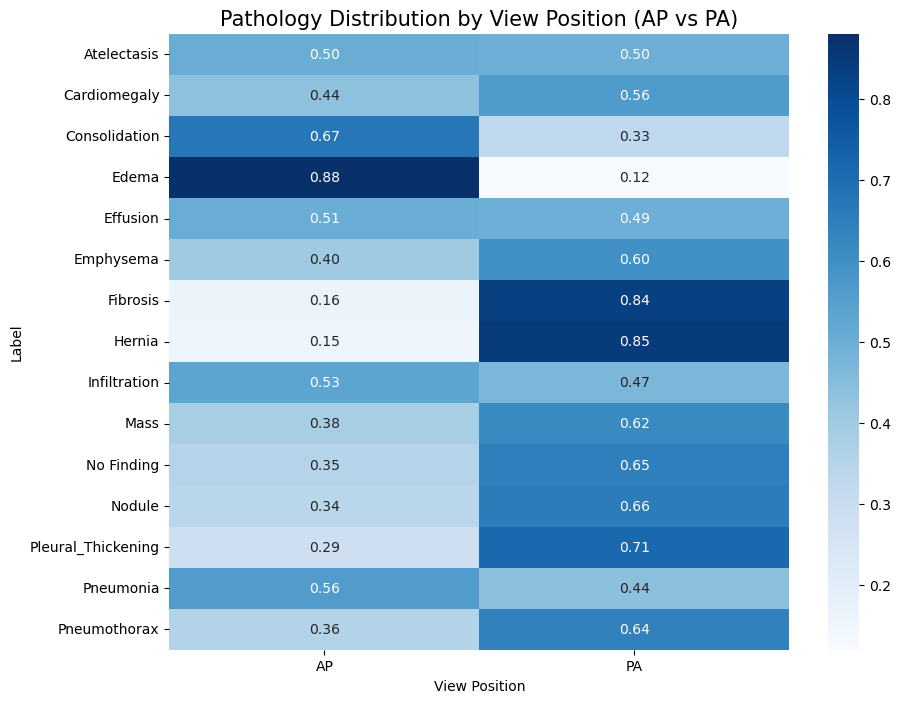

In [8]:
def plot_view_vs_pathology(df):
    # Explode labels to associate each disease with the View Position
    df_exploded = df.assign(Label=df['Finding Labels'].str.split('|')).explode('Label')
    
    # Create a pivot table of counts
    view_pivot = pd.crosstab(df_exploded['Label'], df_exploded['View Position'])
    
    # Normalize by row to show percentage distribution
    view_pivot_pct = view_pivot.div(view_pivot.sum(axis=1), axis=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(view_pivot_pct, annot=True, cmap='Blues', fmt='.2f')
    plt.title('Pathology Distribution by View Position (AP vs PA)', fontsize=15)
    plt.show()

plot_view_vs_pathology(df)

# Multi-Label Thoracic Pathology Classification: ResNet, DenseNet, & MedViT

This repository contains the implementation and comparative study of three deep learning paradigms evaluated on the NIH Chest X-ray14 dataset. This project investigates the efficacy of traditional CNNs against hybrid Vision Transformers for clinical triage.

## 1. Environment Setup

We recommend using **Conda** for environment management to ensure dependency stability.

### **Create and Activate Environment**
```bash
conda create -n capst_env python=3.10 -y
conda activate capst_env
Install Dependencies
pip install torch torchvision timm torchmetrics pandas numpy scikit-learn opencv-python Pillow matplotlib seaborn plotly tqdm ipython
```

## 2. Repository Structure

```text
MedVIT/
├── data/
│   ├── images/              # 112,120 PNG X-ray files (1024x1024)
│   └── Data_Entry_2017.csv  # NIH Metadata and NLP-mined labels
├── experiments/             # Checkpoint storage for .pth files
├── dataset.py               # CLAHE, Letterbox Padding, and Dataset logic
├── data_loader.py           # GroupShuffleSplit (Patient-level)
├── model.py                 # MedViT + Metadata Gating Architecture
├── train.py                 # Training loop (OneCycleLR, AMP, AdamW)
└── visualize_results.py     # Metrics (AUC/PR), Grad-CAM, and Attention Rollout
```

## 3. Data Preparation

- Images: Place all NIH .png files in the /data/images/ directory.

- Leakage Prevention: Our pipeline uses a GroupShuffleSplit keyed to Patient ID. This ensures that no images from a single patient exist in both the training and test sets simultaneously.

- Preprocessing: The code automatically applies CLAHE (Contrast Limited Adaptive Histogram Equalization) to enhance local contrast for subtle pathologies.

## 4. Running the Code
### Training
To train the MedViT model with Metadata Gating:

```bash
python train.py --batch_size 16 --lr 1e-4 --epochs 30 --model medvit
```

### Evaluation & Visualization
To generate performance metrics and PR curves, run the visualization script against your best saved checkpoint:

```bash
python visualize_results.py --model_path "experiments/YOUR_RUN_FOLDER/best_medvit_model.pth"
```

## 5. Technical Highlights

- Hybrid Architecture: MedViT utilizes Shifted Window Attention to capture global anatomical context.

- Metadata Gating: Dynamically fuses image features with Patient Age, Sex, and View Position.

- Imbalance Handling: Implements Weighted Binary Cross-Entropy (BCE) loss to penalize false negatives in rare classes.

- Efficiency: Accelerated via Automatic Mixed Precision (AMP) to optimize GPU memory.

## 6. Troubleshooting

- Windows Users: If your file paths contain spaces (e.g., OneDrive), wrap your --model_path in double quotes: "C:\Users\Name\Path To Model\best.pth".

- CUDA Errors: Verify GPU availability with python -c "import torch; print(torch.cuda.is_available())".

- Memory (OOM): If you encounter Out of Memory errors, decrease the --batch_size to 8 or 4 in train.py.

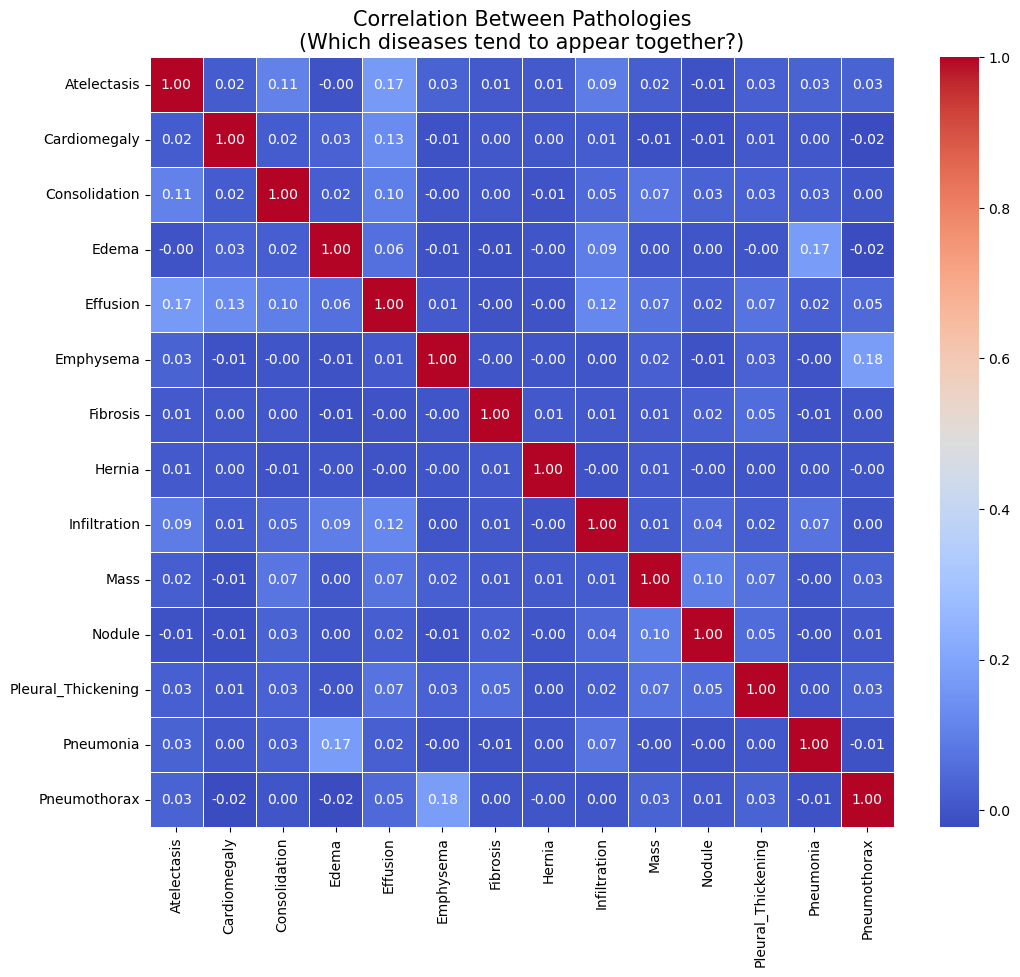

In [ ]:
# 1. Binary Matrix of labels
mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(df['Label_List'])
label_df = pd.DataFrame(label_matrix, columns=mlb.classes_)

# 2. Calculate Correlation
# We remove 'No Finding' to see how the actual diseases relate to each other
if 'No Finding' in label_df.columns:
    label_df = label_df.drop(columns=['No Finding'])

corr_matrix = label_df.corr()

# 3. Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Pathologies\n(Which diseases tend to appear together?)', fontsize=15)
plt.show()